In [1]:
from tqdm import tqdm

from networkx.readwrite import json_graph
import json

import networkx as nx
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from helpers import *

## Graph Overview

In [2]:
G = read_ka2_json(years=[2014], graph_dir='../data/ka2_graphs/', fname_prefix='ka2_mobility_network_')

Y2014 graph has 29 nodes and 170 directed, weighted edges. 
The total number of participants is 1323.


In [3]:
selfloops = nx.selfloop_edges(G)
cleanG = G.copy()
cleanG.remove_edges_from(selfloops)

### Cumulative Graph

In [4]:
start = 2014
end = 2016
G = read_ka2_json(years=np.arange(start, end+1, 1), graph_dir='../data/ka2_graphs/', fname_prefix='ka2_mobility_network_')

Y2014-2015-2016 graph has 33 nodes and 862 directed, weighted edges. 
The total number of participants is 64306.


In [5]:
selfloops = nx.selfloop_edges(G)
cleanG = G.copy()
cleanG.remove_edges_from(selfloops)

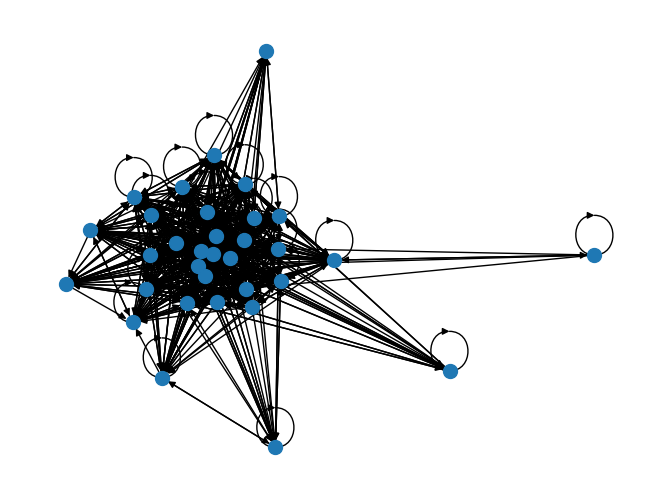

In [6]:
nx.draw(G, node_size=100)

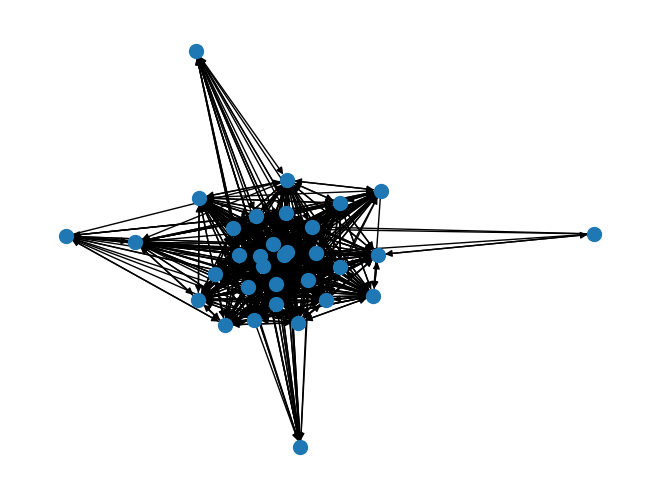

In [7]:
nx.draw(cleanG, node_size=100)

### Configuration Model

In [6]:
randG = digraph_config_model(G, weight='weight')
randG.number_of_nodes()

33

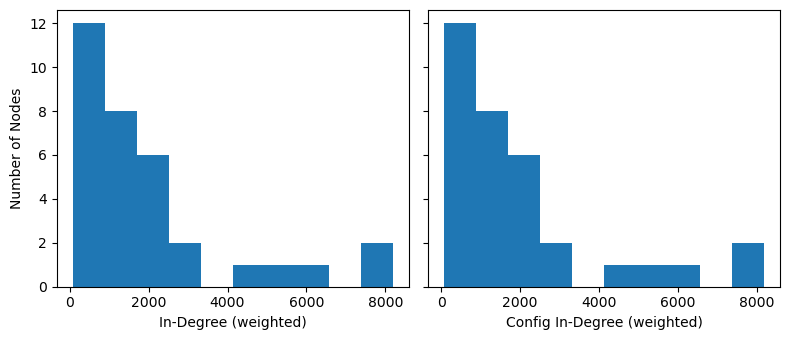

In [8]:
# sanity check: if the weighted degree sequence can be recovered from the configuration model
in_degrees = dict(G.in_degree(weight='weight'))
rand_in_degrees = dict(randG.in_degree(weight='weight'))
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
axs[0].hist(in_degrees.values())
axs[1].hist(rand_in_degrees.values())
axs[0].set_ylabel('Number of Nodes')
axs[0].set_xlabel('In-Degree (weighted)')
axs[1].set_xlabel('Config In-Degree (weighted)')
plt.tight_layout()
plt.show()

## Properties

### Degree Distribution

In [10]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
weights = nx.get_edge_attributes(G, name='weight')

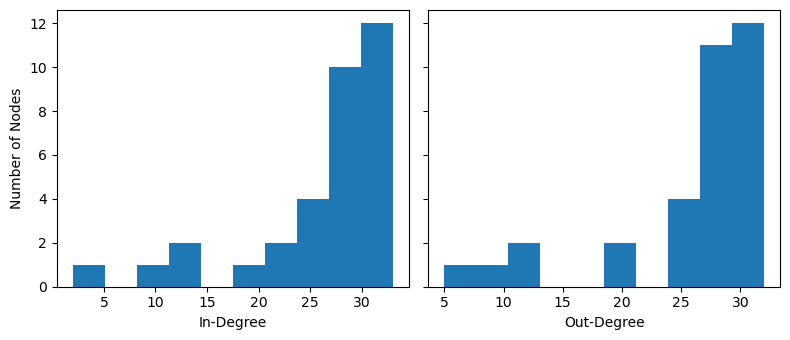

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
axs[0].hist(in_degrees.values())
axs[1].hist(out_degrees.values())
axs[0].set_ylabel('Number of Nodes')
axs[0].set_xlabel('In-Degree')
axs[1].set_xlabel('Out-Degree')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of Country-Country Mobility Edges')

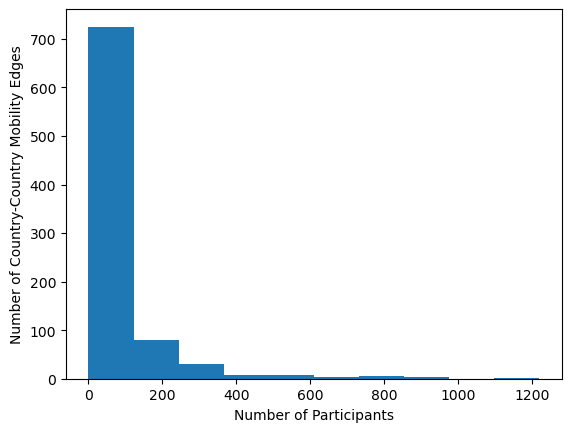

In [12]:
plt.hist(weights.values())
plt.xlabel('Number of Participants')
plt.ylabel('Number of Country-Country Mobility Edges')

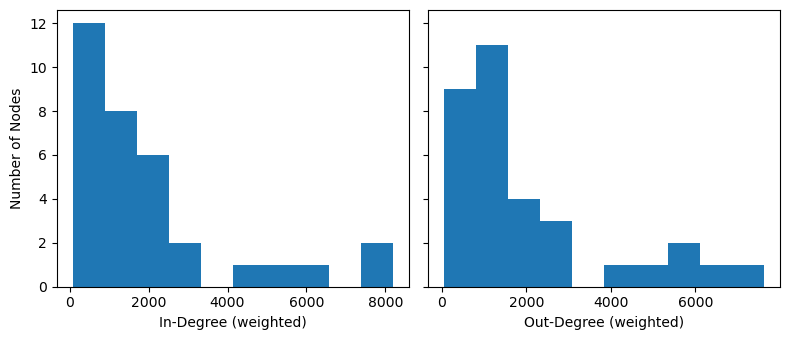

In [13]:
in_degrees = dict(G.in_degree(weight='weight'))
out_degrees = dict(G.out_degree(weight='weight'))
fig, axs = plt.subplots(1, 2, figsize=(8, 3.5), sharey=True)
axs[0].hist(in_degrees.values())
axs[1].hist(out_degrees.values())
axs[0].set_ylabel('Number of Nodes')
axs[0].set_xlabel('In-Degree (weighted)')
axs[1].set_xlabel('Out-Degree (weighted)')
plt.tight_layout()
plt.show()

We remove self-loop edges before calculating centrality to focuse on only international mobiliy trends.

In [14]:
distance = {e:1/w for e, w in nx.get_edge_attributes(cleanG, name='weight').items()}
nx.set_edge_attributes(cleanG, distance, 'distance')

In [15]:
%%time
close_cen = nx.closeness_centrality(cleanG, distance='distance')
eigen_cen = nx.eigenvector_centrality(cleanG, weight='weight')

CPU times: user 41.3 ms, sys: 87 μs, total: 41.4 ms
Wall time: 40.2 ms


In [16]:
sorted(close_cen.items(), key=lambda c: c[1], reverse=True)

[('ES - Spain', 79.13161921877598),
 ('IT - Italy', 78.85086536649744),
 ('DE - Germany', 76.27106886778675),
 ('PL - Poland', 75.49269215948596),
 ('FR - France', 72.83487170186977),
 ('RO - Romania', 66.0650196191774),
 ('UK - United Kingdom', 64.65488797410882),
 ('EL - Greece', 63.77235379505276),
 ('PT - Portugal', 63.18175614340892),
 ('FI - Finland', 63.17263712658451),
 ('LT - Lithuania', 63.14885850515397),
 ('BG - Bulgaria', 60.84029615950129),
 ('HU - Hungary', 59.28345494407668),
 ('CZ - Czechia', 57.72396324028265),
 ('NL - Netherlands', 57.14397422935927),
 ('SE - Sweden', 54.72305443988371),
 ('HR - Croatia', 52.86378108191218),
 ('AT - Austria', 51.41659010322067),
 ('LV - Latvia', 50.12685590923217),
 ('SK - Slovakia', 48.358843699514495),
 ('BE - Belgium', 48.290310487225646),
 ('NO - Norway', 47.34582878232363),
 ('DK - Denmark', 42.30010150691245),
 ('SI - Slovenia', 41.79074186497226),
 ('IE - Ireland', 41.38699414314499),
 ('TR - Turkey', 40.92546467143343),
 ('CY

In [17]:
sorted(eigen_cen.items(), key=lambda c: c[1], reverse=True)

[('ES - Spain', 0.4847530327186432),
 ('IT - Italy', 0.44866062072019103),
 ('DE - Germany', 0.3731155447115944),
 ('PL - Poland', 0.3264096577958158),
 ('FR - France', 0.30519523374340585),
 ('RO - Romania', 0.1768784345185987),
 ('UK - United Kingdom', 0.17227436551304254),
 ('EL - Greece', 0.1532725273088949),
 ('PT - Portugal', 0.14198535111493038),
 ('FI - Finland', 0.13806497631329875),
 ('LT - Lithuania', 0.12487237358943802),
 ('BG - Bulgaria', 0.11530851483974586),
 ('CZ - Czechia', 0.11007976498410894),
 ('NL - Netherlands', 0.10413886937344004),
 ('HU - Hungary', 0.10229878009577355),
 ('SE - Sweden', 0.0828309678395618),
 ('HR - Croatia', 0.07529999349449477),
 ('LV - Latvia', 0.06797840742218686),
 ('AT - Austria', 0.06310822781495906),
 ('TR - Turkey', 0.05717302754962805),
 ('NO - Norway', 0.051561247776443525),
 ('SK - Slovakia', 0.04767406760907762),
 ('SI - Slovenia', 0.04437408502006352),
 ('DK - Denmark', 0.04414473397129854),
 ('BE - Belgium', 0.04251405845920288),

### Core-Periphery

In [14]:
core = max(nx.strongly_connected_components(G), key=len)
core = G.copy().subgraph(core)

core_mobility_vol = sum(nx.get_edge_attributes(core, 'weight').values())
G_mobility_vol = sum(nx.get_edge_attributes(G, 'weight').values())

directed = 'directed' if core.is_directed() else 'undirected'
weighted = 'weighted' if nx.is_weighted(core) else 'unweighted'

print(f'Y{start}-{end} graph has a giant component with {core.number_of_nodes()} nodes ({len(core)/len(G)*100:.2f}%) and {core.number_of_edges()} {directed}, {weighted} edges ({core.number_of_edges()/G.number_of_edges()*100:.2f}%). ')
print(f'The giant component covers mobility volume of {core_mobility_vol} participants ({core_mobility_vol/G_mobility_vol*100:.2f}%).')

Y2014-2016 graph has a giant component with 33 nodes (100.00%) and 862 directed, weighted edges (100.00%). 
The giant component covers mobility volume of 64306 participants (100.00%).


### Clustering

In [15]:
cluster_coef = nx.clustering(cleanG, weight="weight")
rand_cluster_coef = nx.clustering(randG, weight='weight')

In [16]:
print(f'Average local clustering coefficient in the observed mobility network is {np.mean(list(cluster_coef.values()))}, and that of one configuration model network is {np.mean(list(rand_cluster_coef.values()))}')

Average local clustering coefficient in the observed mobility network is 0.03844133020112119, and that of one configuration model network is 0.0419407463673711


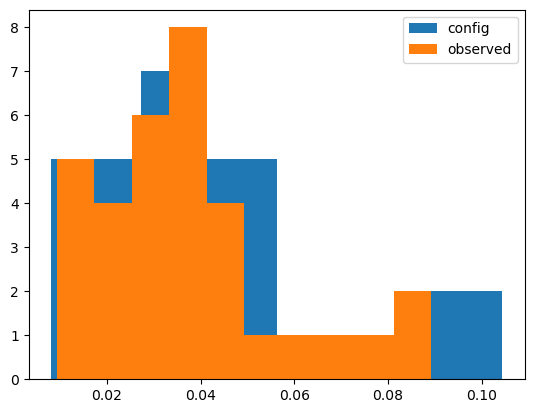

In [17]:
plt.hist(rand_cluster_coef.values(), label='config')
plt.hist(cluster_coef.values(), label='observed')
plt.legend()
plt.show()

### Attribute Assortativity

In [18]:
culture = nx.get_node_attributes(G, 'geographical_cultural_region')
econ = nx.get_node_attributes(G, 'economic_family')

#### Economic

In [19]:
mapping = {l:ind for ind, l in enumerate(sorted(set(econ.values())))}
mat = nx.attribute_mixing_matrix(G, attribute='economic_family', mapping=mapping)
wmat = weight_attribute_mixing_matrix(G, attribute='economic_family', mapping=mapping)

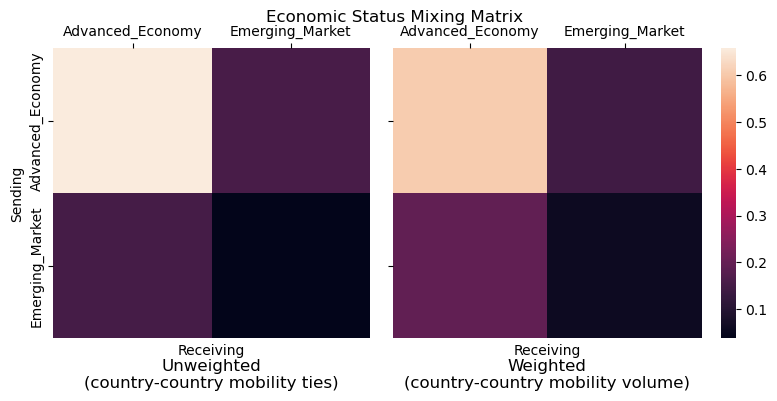

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True, gridspec_kw={'width_ratios': [45, 55]})
vmin = np.min([mat, wmat])
vmax = np.max([mat, wmat])

# non weighted (% cross-organization mobility)
df_heat = pd.DataFrame(mat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False)
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')
axs[0].set_title('Unweighted\n(country-country mobility ties)', y=-0.2)

# weighted (% participants)
df_heat = pd.DataFrame(wmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, cbar=True)
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
axs[1].set_title('Weighted\n(country-country mobility volume)', y=-0.2)
plt.tight_layout()
plt.suptitle('Economic Status Mixing Matrix', y=1)
plt.show()

In [21]:
relattribute_mixmat, lower, upper =  obs_config_attribute_mixmat(G, attribute='economic_family', mapping=mapping)
relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute='economic_family', weight='weight', mapping=mapping)

100%|██████████| 50/50 [00:08<00:00,  5.66it/s]


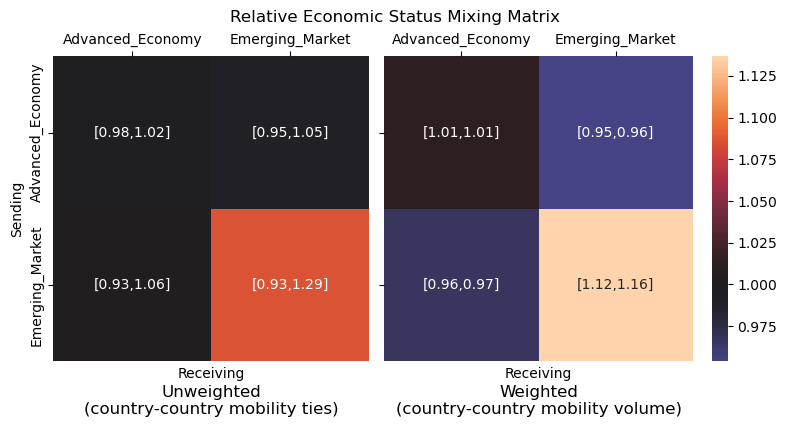

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(8,4.5), sharey=True,
                       gridspec_kw={'width_ratios': [45, 55]})
vmin = np.min([relattribute_mixmat, relattribute_wmixmat])
vmax = np.max([relattribute_mixmat, relattribute_wmixmat])

# non weighted (% cross-organization mobility - obs/config) 
lower_mat = np.char.mod('%.2f', lower)
upper_mat = np.char.mod('%.2f', upper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]
df_heat = pd.DataFrame(relattribute_mixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False, annot=labels, fmt='', center=1)
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')
axs[0].set_title('Unweighted\n(country-country mobility ties)', y=-0.2)

# weighted (% participants - obs/config)
lower_mat = np.char.mod('%.2f', wlower)
upper_mat = np.char.mod('%.2f', wupper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]

df_heat = pd.DataFrame(relattribute_wmixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, annot=labels, fmt='', center=1)
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
axs[1].set_title('Weighted\n(country-country mobility volume)', y=-0.2)
plt.tight_layout()
plt.suptitle('Relative Economic Status Mixing Matrix', y=.95)

plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tight_layout()
plt.show()

In [23]:
mapping = {l:ind for ind, l in enumerate(sorted(set(culture.values())))}
mat = nx.attribute_mixing_matrix(G, attribute='geographical_cultural_region', mapping=mapping)
wmat = weight_attribute_mixing_matrix(G, attribute='geographical_cultural_region', mapping=mapping)

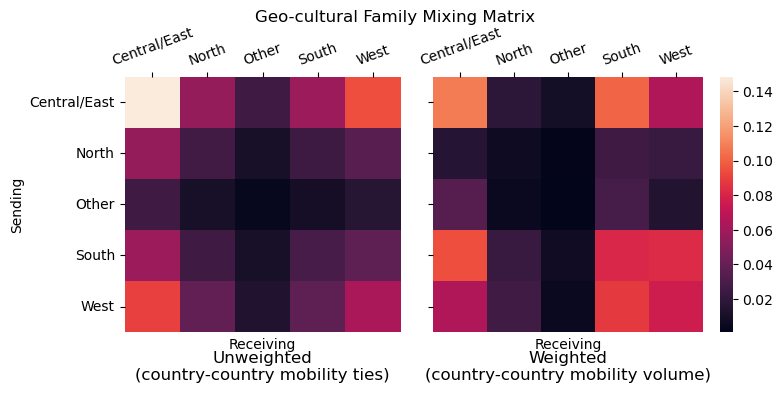

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(8,4), sharey=True,
                        gridspec_kw={'width_ratios': [45, 55]}
                       )
vmin = np.min([mat, wmat])
vmax = np.max([mat, wmat])

# non weighted (% cross-organization mobility)
df_heat = pd.DataFrame(mat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False)
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].tick_params(axis='x', labelrotation=20)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')
axs[0].set_title('Unweighted\n(country-country mobility ties)', y=-0.22)

# weighted (% participants)
df_heat = pd.DataFrame(wmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, cbar=True)
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].tick_params(axis='x', labelrotation=20)
axs[1].set_xlabel('Receiving')
axs[1].set_title('Weighted\n(country-country mobility volume)', y=-0.22)
plt.tight_layout()
plt.suptitle('Geo-cultural Family Mixing Matrix', y=1)
plt.show()

In [25]:
relattribute_mixmat, lower, upper =  obs_config_attribute_mixmat(G, attribute='geographical_cultural_region', mapping=mapping)
relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute='geographical_cultural_region', weight='weight', mapping=mapping)

100%|██████████| 50/50 [00:08<00:00,  5.80it/s]


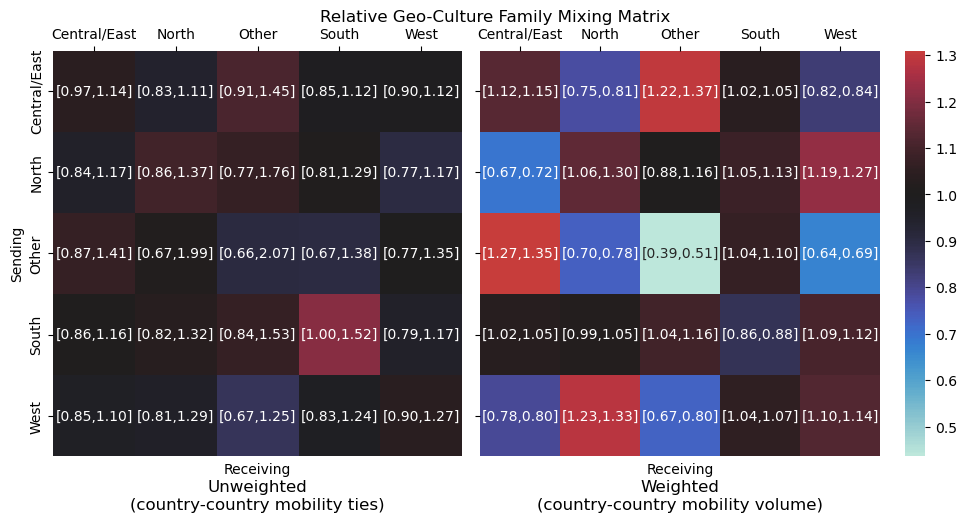

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5.5), sharey=True,
                       gridspec_kw={'width_ratios': [45, 55]})
vmin = np.min([relattribute_mixmat, relattribute_wmixmat])
vmax = np.max([relattribute_mixmat, relattribute_wmixmat])

# non weighted (% cross-organization mobility - obs/config) 
lower_mat = np.char.mod('%.2f', lower)
upper_mat = np.char.mod('%.2f', upper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]
df_heat = pd.DataFrame(relattribute_mixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[0], vmin=vmin, vmax=vmax, cbar=False, annot=labels, fmt='', center=1)
axs[0].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[0].set_xlabel('Receiving')
axs[0].set_ylabel('Sending')
axs[0].set_title('Unweighted\n(country-country mobility ties)', y=-0.15)

# weighted (% participants - obs/config)
lower_mat = np.char.mod('%.2f', wlower)
upper_mat = np.char.mod('%.2f', wupper)
labels = [
        [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
        for row1, row2 in zip(lower_mat, upper_mat)
        ]

df_heat = pd.DataFrame(relattribute_wmixmat, columns=mapping.keys(), index=mapping.keys())
sns.heatmap(df_heat, ax=axs[1], vmin=vmin, vmax=vmax, annot=labels, fmt='', center=1)
axs[1].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
axs[1].set_xlabel('Receiving')
axs[1].set_title('Weighted\n(country-country mobility volume)', y=-0.15)
plt.tight_layout()
plt.suptitle('Relative Geo-Culture Family Mixing Matrix', y=.95)

plt.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.tight_layout()
plt.show()

## Temporal Analysis

### UK centrality over time

In [27]:
def short_country_name(country: str) -> str:
    """Return the country code from labels like 'FI - Finland'."""
    return str(country).split(" - ")[0]

In [28]:
def build_centrality_df(graph, period=None) -> pd.DataFrame:
    """Calculate period-level hub and bridge metrics."""
    rows = []

    in_strength = dict(graph.in_degree(weight="weight"))
    out_strength = dict(graph.out_degree(weight="weight"))
    total_strength = {
        node: in_strength.get(node, 0) + out_strength.get(node, 0)
        for node in graph.nodes()
    }

    pagerank = nx.pagerank(graph, weight="weight")

    # For betweenness, edge weights need to behave like distances.
    # Strong mobility links are treated as short distances.
    distance_graph = graph.copy()
    nx.set_edge_attributes(
        distance_graph,
        {(u, v): 1 / attrs.get("weight", 1) for u, v, attrs in distance_graph.edges(data=True)},
        "distance",
    )
    betweenness = nx.betweenness_centrality(distance_graph, weight="distance", normalized=True)
    closeness = nx.closeness_centrality(distance_graph, distance="distance", wf_improved=False)

    for country in graph.nodes():
        rows.append({
            # "period": period,
            "country": country,
            "country_code": short_country_name(country),
            "in_strength": in_strength.get(country, 0),
            "out_strength": out_strength.get(country, 0),
            "total_strength": total_strength.get(country, 0),
            "net_flow": in_strength.get(country, 0) - out_strength.get(country, 0),
            "pagerank": pagerank.get(country, 0),
            "betweenness": betweenness.get(country, 0),
            "closeness": closeness.get(country, 0),
        })
    df = pd.DataFrame(rows)
    if period:
        df["period"] = period
    return df

In [29]:
df = []

for year in tqdm(np.arange(2014, 2023, 1)): # 2023 excluded due to data availablity
    
    G = nx.DiGraph()
    with open(f'../data/ka2_graphs/ka2_mobility_network_{year}.json', 'r') as f:
        data = json.load(f)
        G.update(json_graph.node_link_graph(data, source='source', target='target', edges='edges'))
        
    # remove self loops
    selfloops = nx.selfloop_edges(G)
    G.remove_edges_from(selfloops)

    # remove isolates
    isolates = [v for v in nx.isolates(G)]
    G.remove_nodes_from(isolates)
    
    # print(G.number_of_nodes(), G.number_of_edges(), sum(dict(G.in_degree(weight='weight')).values()))

    df.append(build_centrality_df(G, period=year))

df = pd.concat(df)

100%|██████████| 9/9 [00:00<00:00, 10.55it/s]


/tmp/ipykernel_505/1205002863.py:14: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([l1, l2], labels=['pagerank', 'closeness'], loc='upper left', bbox_to_anchor=(0.12, 0., 0.5, 0.88))


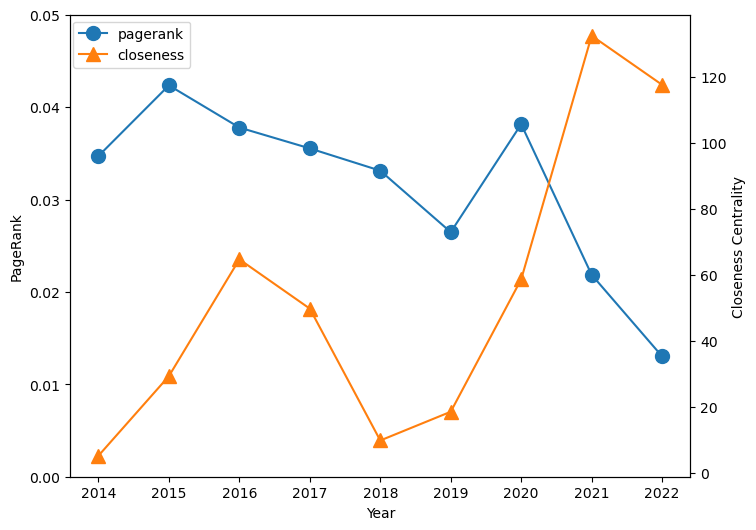

In [30]:
plot_data = df[df['country_code']=='UK']

fig, ax = plt.subplots(figsize=(8,6))

l1 = ax.plot(plot_data['period'], plot_data['pagerank'], marker='o', color='tab:blue', markersize=10)
ax.set_ylim(0, 0.05)
ax.set_ylabel('PageRank')
ax.set_xlabel('Year')

ax2 = ax.twinx()
l2 = ax2.plot(plot_data['period'], plot_data['closeness'], marker='^', color='tab:orange', markersize=10)
ax2.set_ylabel('Closeness Centrality')

fig.legend([l1, l2], labels=['pagerank', 'closeness'], loc='upper left', bbox_to_anchor=(0.12, 0., 0.5, 0.88))
plt.show()

### Network Global trends

In [31]:
def giant_proportion(graph):
    core = max(nx.strongly_connected_components(graph), key=len)
    core = graph.copy().subgraph(core)

    core_mobility_vol = sum(nx.get_edge_attributes(core, 'weight').values())
    G_mobility_vol = sum(nx.get_edge_attributes(graph, 'weight').values())
    
    return len(core)/len(graph), core_mobility_vol/G_mobility_vol

In [32]:
def global_measures(graph, period=None) -> pd.DataFrame:
    """Calculate period-level hub and bridge metrics."""
    rows = []

    in_strength = list(dict(graph.in_degree(weight="weight")).values())
    out_strength = list(dict(graph.out_degree(weight="weight")).values())
    
    nx.set_edge_attributes(
        graph,
        {(u, v): 1 / attrs.get("weight", 1) for u, v, attrs in graph.edges(data=True)},
        "distance",
    )
    
    giant_nprop, giant_sprop = giant_proportion(graph)
    
    measures_dict = {"in_gini": gini(np.array(in_strength)),
                     "out_gini": gini(np.array(out_strength)),
                     "clustering": nx.average_clustering(graph, weight="weight"),
                     "shortest_path_length": nx.average_clustering(graph, weight="distance"),
                     "giant_nprop": giant_nprop,
                     "giant_sprop": giant_sprop,
                    }
    if period:
        measures_dict["period"] = period
    return measures_dict

In [33]:
df = []

for year in tqdm(np.arange(2014, 2023, 1)): # 2023 excluded due to data availablity
    
    G = nx.DiGraph()
    with open(f'../data/ka2_graphs/ka2_mobility_network_{year}.json', 'r') as f:
        data = json.load(f)
        G.update(json_graph.node_link_graph(data, source='source', target='target', edges='edges'))
        
    # remove self loops
    selfloops = nx.selfloop_edges(G)
    G.remove_edges_from(selfloops)

    # remove isolates
    isolates = [v for v in nx.isolates(G)]
    G.remove_nodes_from(isolates)
    
    # print(G.number_of_nodes(), G.number_of_edges(), sum(dict(G.in_degree(weight='weight')).values()))

    df.append(global_measures(G, period=year))

df = pd.DataFrame(data=df)

100%|██████████| 9/9 [00:04<00:00,  2.00it/s]


/tmp/ipykernel_505/1176579366.py:13: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([l1, l2], labels=['in-strength', 'out-strength'], loc='lower right', bbox_to_anchor=(0.4, 0.12, 0.5, 0.5))


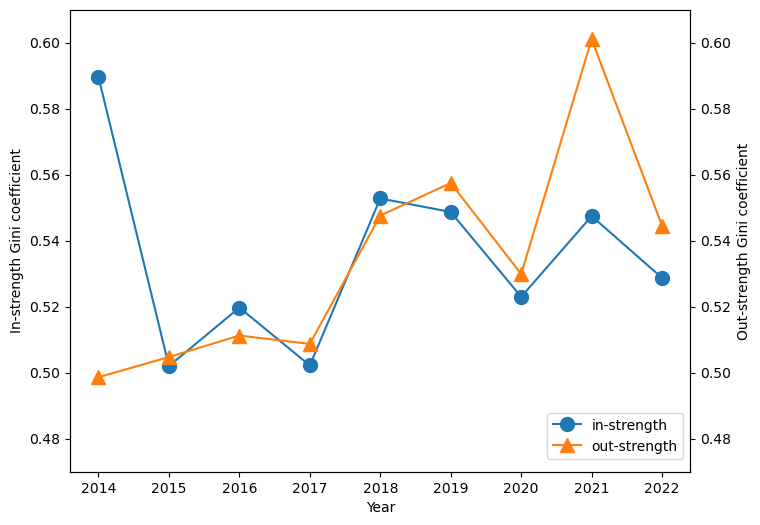

In [34]:
fig, ax = plt.subplots(figsize=(8,6))

l1 = ax.plot(df['period'], df['in_gini'], marker='o', color='tab:blue', markersize=10)
ax.set_ylim(0.47, 0.61)
ax.set_ylabel('In-strength Gini coefficient')
ax.set_xlabel('Year')

ax2 = ax.twinx()
l2 = ax2.plot(df['period'], df['out_gini'], marker='^', color='tab:orange', markersize=10)
ax2.set_ylim(0.47, 0.61)
ax2.set_ylabel('Out-strength Gini coefficient')

fig.legend([l1, l2], labels=['in-strength', 'out-strength'], loc='lower right', bbox_to_anchor=(0.4, 0.12, 0.5, 0.5))
plt.show()

/tmp/ipykernel_505/3510832046.py:12: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([l1, l2], labels=['clustering', 'shortest path'], loc='upper right', bbox_to_anchor=(0.4, 0.38, 0.5, 0.5))


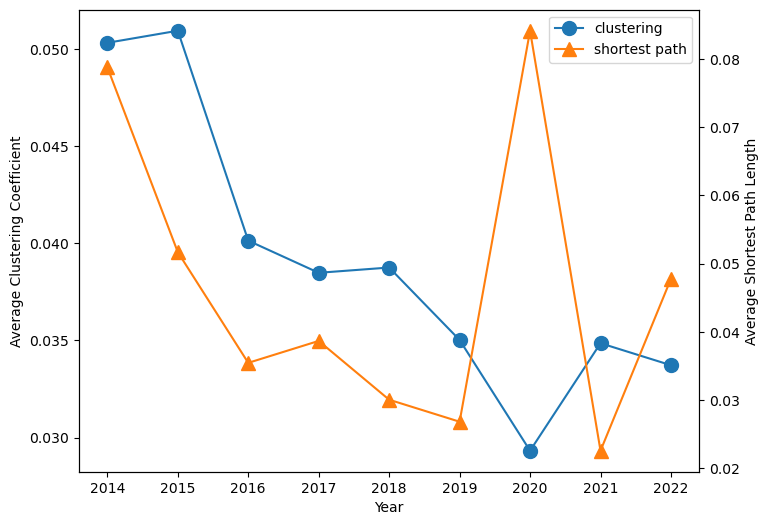

In [35]:
fig, ax = plt.subplots(figsize=(8,6))

l1 = ax.plot(df['period'], df['clustering'], marker='o', color='tab:blue', markersize=10)
# ax.set_ylim(0, 0.05)
ax.set_ylabel('Average Clustering Coefficient')
ax.set_xlabel('Year')

ax2 = ax.twinx()
l2 = ax2.plot(df['period'], df['shortest_path_length'], marker='^', color='tab:orange', markersize=10)
ax2.set_ylabel('Average Shortest Path Length')

fig.legend([l1, l2], labels=['clustering', 'shortest path'], loc='upper right', bbox_to_anchor=(0.4, 0.38, 0.5, 0.5))
plt.show()

/tmp/ipykernel_505/2326319129.py:13: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  fig.legend([l1, l2], labels=['size', 'strength'], loc='lower right', bbox_to_anchor=(0.4, 0.12, 0.5, 0.5))


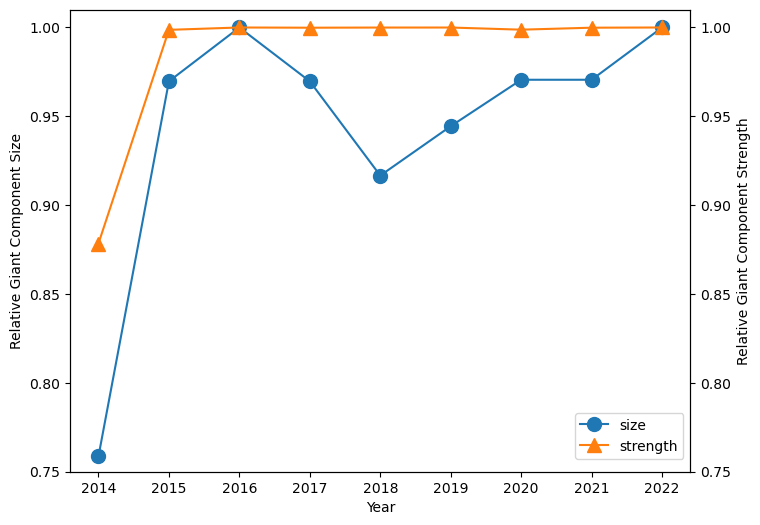

In [36]:
fig, ax = plt.subplots(figsize=(8,6))

l1 = ax.plot(df['period'], df['giant_nprop'], marker='o', color='tab:blue', markersize=10)
ax.set_ylim(0.75, 1.01)
ax.set_ylabel('Relative Giant Component Size')
ax.set_xlabel('Year')

ax2 = ax.twinx()
l2 = ax2.plot(df['period'], df['giant_sprop'], marker='^', color='tab:orange', markersize=10)
ax2.set_ylim(0.75, 1.01)
ax2.set_ylabel('Relative Giant Component Strength')

fig.legend([l1, l2], labels=['size', 'strength'], loc='lower right', bbox_to_anchor=(0.4, 0.12, 0.5, 0.5))
plt.show()

In [37]:
def period_attr_rela_wmixmat(period, graph_dir='../data/ka2_graphs/', fname_prefix='ka2_mobility_network_', attribute=str):
    start = period[0]
    end = period[-1]
    G = read_ka2_json(years=np.arange(start, end+1, 1), graph_dir=graph_dir, fname_prefix=fname_prefix)
    
    attr = nx.get_node_attributes(G, attribute)
    mapping = {l:ind for ind, l in enumerate(sorted(set(attr.values())))}
    relattribute_wmixmat, wlower, wupper =  obs_config_attribute_mixmat(G, attribute=attribute, weight='weight', mapping=mapping)
    
    lower_mat = np.char.mod('%.2f', wlower)
    upper_mat = np.char.mod('%.2f', wupper)
    labels = [
            [f"[{item1},{item2}]" for item1, item2 in zip(row1, row2)]
            for row1, row2 in zip(lower_mat, upper_mat)
            ]

    return relattribute_wmixmat, labels, mapping

In [38]:
periods = [np.arange(2014, 2017, 1), np.arange(2017, 2020, 1), np.arange(2020, 2023, 1)]
mats = []
labels = []
mappings = []
for p in periods:
    p_mat, p_labs, p_maps = period_attr_rela_wmixmat(p, attribute='geographical_cultural_region')
    mats.append(p_mat)
    labels.append(p_labs)
    mappings.append(p_maps)

Y2014-2015-2016 graph has 33 nodes and 862 directed, weighted edges. 
The total number of participants is 64306.


100%|██████████| 50/50 [00:08<00:00,  5.75it/s]


Y2017-2018-2019 graph has 39 nodes and 1014 directed, weighted edges. 
The total number of participants is 142770.


100%|██████████| 50/50 [00:18<00:00,  2.64it/s]


Y2020-2021-2022 graph has 34 nodes and 1032 directed, weighted edges. 
The total number of participants is 215877.


100%|██████████| 50/50 [00:28<00:00,  1.75it/s]


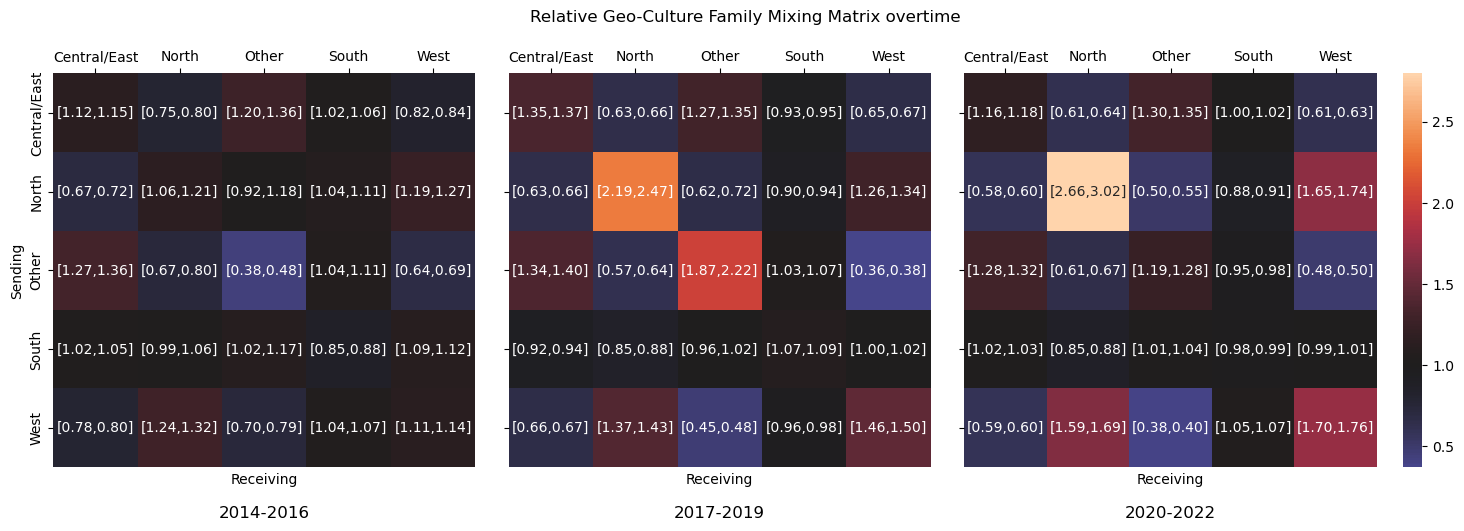

In [39]:
fig, axs = plt.subplots(1, len(periods), 
                        sharey=True,
                        figsize=(5*len(periods), 5),
                        gridspec_kw={'width_ratios': [45, 45, 55]}, 
                       )
vmin = np.min(mats)
vmax = np.max(mats)

for i in range(len(periods)):
    
    if i == len(periods) - 1:
        cbar = True
    else:
        cbar = False
        
    df_heat = pd.DataFrame(mats[i], columns=mappings[i].keys(), index=mappings[i].keys())
    sns.heatmap(df_heat, ax=axs[i], vmin=vmin, vmax=vmax, cbar=cbar, annot=labels[i], fmt='', center=1)
    axs[i].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    axs[i].set_xlabel('Receiving')
    
    if i == 0:
        axs[i].set_ylabel('Sending')
        
    axs[i].set_title(f'{periods[i][0]}-{periods[i][-1]}', y=-0.15)

plt.tight_layout()
plt.suptitle('Relative Geo-Culture Family Mixing Matrix overtime', y=1.05)
plt.show()

## Misc

In [16]:
adj_G = nx.adjacency_matrix(G, weight='weight').toarray()

adj_randG = np.zeros(adj_G.shape)
niter = 50
for _ in range(niter):
    randG = digraph_config_model(G)
    adj_randG += nx.adjacency_matrix(randG, weight='weight').toarray()
adj_randG /= niter

data = (adj_G-adj_randG)/(adj_G+adj_randG)
# data[np.isnan(data)] = 1
# data[np.isneginf(data)] = -1

/tmp/ipykernel_352/3862546278.py:10: RuntimeWarning: invalid value encountered in divide
  data = (adj_G-adj_randG)/(adj_G+adj_randG)


<Axes: >

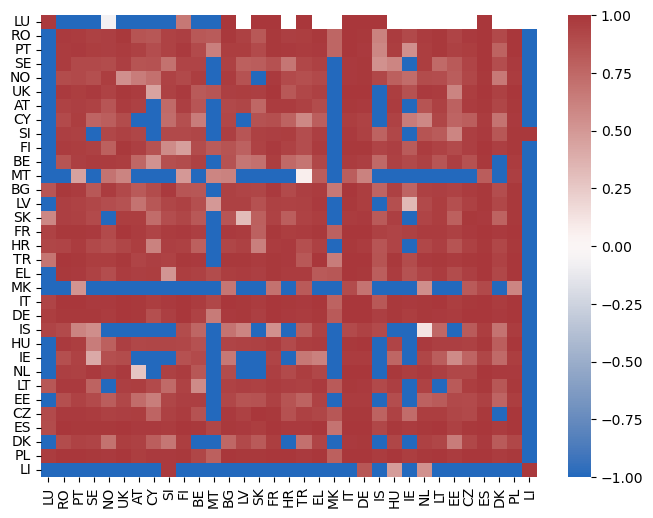

In [20]:
plt.figure(figsize=(8,6))
tick_labels = list(map(lambda x: x[:2], G.nodes()))
df_heat = pd.DataFrame(data, columns=tick_labels, index=tick_labels)
sns.heatmap(df_heat, 
            cmap='vlag', center=0, 
            xticklabels=True, yticklabels=True)

### Linguistics

In [12]:
def lang_edgetype(G, name='language_family', normalize=True):
    
    lang = nx.get_node_attributes(G, name)
    
    lang_edgetypes = {}

    for s, t, w in G.edges(data="weight"):

        langsim = language_similarity(lang[s], lang[t])

        if langsim in lang_edgetypes:
            lang_edgetypes[langsim]["pair"] += 1
            lang_edgetypes[langsim]["weighted"] += w
        else:
            lang_edgetypes[langsim]={"pair": 1,
                                     "weighted": w
                                    }
            
    if normalize:
        total_pair = G.number_of_edges()
        total_strength = sum(nx.get_edge_attributes(G, "weight").values())
        
        for langsim in lang_edgetypes:
            lang_edgetypes[langsim]["pair"] /= total_pair 
            lang_edgetypes[langsim]["weighted"] /= total_strength 
    
    return lang_edgetypes

In [29]:
df_obs = []
df_gap = []
niter = 50

for year in tqdm(np.arange(2014, 2023, 1)): # 2023 excluded due to data availablity
    
    G = nx.DiGraph()
    with open(f'../data/ka2_graphs/ka2_mobility_network_{year}.json', 'r') as f:
        data = json.load(f)
        G.update(json_graph.node_link_graph(data, source='source', target='target', edges='edges'))
        
    # remove self loops
    selfloops = nx.selfloop_edges(G)
    G.remove_edges_from(selfloops)

    # remove isolates
    isolates = [v for v in nx.isolates(G)]
    G.remove_nodes_from(isolates)
    
    add_df = pd.DataFrame(lang_edgetype(G)).T
    add_df.index.rename('langsim', inplace=True)
    
    
    rand_add_df = pd.DataFrame(np.zeros(add_df.shape), 
                               index=add_df.index, columns=add_df.columns)
    for i in range(niter):
        randG = digraph_config_model(G, weight='weight')
        this_df = pd.DataFrame(lang_edgetype(G)).T
        this_df.index.rename('langsim', inplace=True) 
        rand_add_df += this_df
    
    rand_add_df /= niter
    gap_df = add_df - rand_add_df 
    gap_df['year'] = year
    df_gap.append(gap_df)
    
    add_df['year'] = year
    df_obs.append(add_df)

df_obs = pd.concat(df_obs)
df_gap = pd.concat(df_gap)

100%|██████████| 9/9 [01:44<00:00, 11.60s/it]


<Axes: xlabel='year', ylabel='pair'>

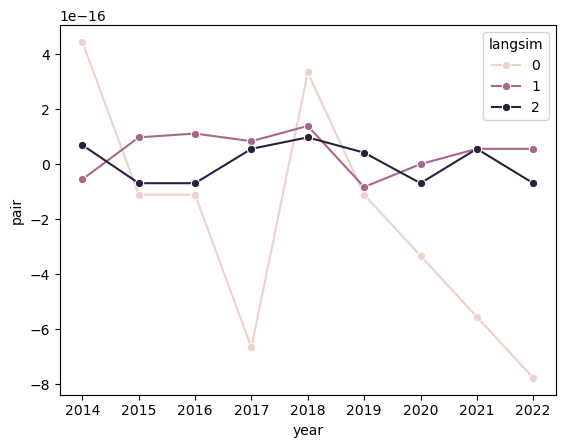

In [34]:
import seaborn as sns
sns.lineplot(df, x='year', y='pair', hue='langsim', marker='o')
plt.xlabel('Year')
plt.xlabel('Year')

<Axes: xlabel='year', ylabel='weighted'>

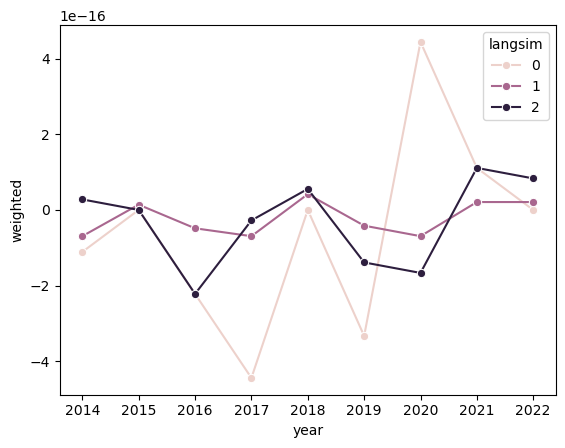

In [35]:
sns.lineplot(df, x='year', y='weighted', hue='langsim', marker='o')

### Mobility Stats

In [ ]:
node_stats = {}

for s, t, w in G.edges(data='weight'):
    if s != t:
        if s in node_stats:
            node_stats[s]['out'] += w
        else:
            node_stats[s] = {'out': w,
                             'in': 0,
                             'self': 0
                            }

        if t in node_stats:
            node_stats[t]['in'] += w
        else:
            node_stats[t] = {'out': 0,
                             'in': w,
                             'self': 0
                            }
    else:
        if s in node_stats:
            node_stats[s]['self'] += w
        else:
            node_stats[s] = {'out': 0,
                             'in': 0,
                             'self': w
                            }
node_stats = pd.DataFrame(node_stats).T.reset_index(names=['country'])
plot_data = node_stats.melt(id_vars='country', value_vars=['in', 'out', 'self'], 
                           var_name='mobility', value_name='num_participants')

In [ ]:
order = node_stats.sort_values('self', ascending=False).country
plt.figure(figsize=(8,6))
sns.barplot(plot_data, x='country', y='num_participants', hue='mobility', order=order.values)
plt.xticks(ticks=order.values, labels=order.apply(lambda x: x[:2]).values, rotation=90)
plt.yscale('log')
plt.show()

In [ ]:
plt.bar(node_stats['country'].apply(lambda x: x[:2]), node_stats['in']-node_stats['out'])
plt.xticks(rotation=90)
plt.grid(True)
# plt.yscale('log')
plt.show()